Link video presentasi : https://youtu.be/ANnizIqKw-4

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
features_df = pd.read_csv('A.csv')
targets_df = pd.read_csv('A_targets.csv')
df = pd.merge(features_df, targets_df, on='Student_ID')
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


## 2. Exploratory Data Analysis (EDA)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [35]:
df.describe().round(2)

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00
mean,2500.50,8.28,74.54,74.54,0.34,4.04,72.04,5.53,2.13,3.73,3.03,4.12,3.7,2.84,6.96,6.02,13.90
std,1443.52,1.01,10.27,10.24,0.61,1.97,7.72,2.05,1.14,1.28,1.41,0.72,1.6,1.78,1.15,2.85,6.25
min,1.00,5.00,50.00,50.00,0.00,0.00,44.70,0.00,0.00,1.00,1.00,1.00,0.0,0.00,4.00,1.00,0.00
25%,1250.75,7.61,67.40,67.60,0.00,2.70,66.60,4.00,1.00,3.00,2.00,4.00,3.0,2.00,6.20,4.00,12.51
50%,2500.50,8.32,74.70,74.80,0.00,4.00,72.05,6.00,2.00,4.00,3.00,4.00,4.0,3.00,7.00,6.00,15.76
75%,3750.25,9.02,82.00,81.70,1.00,5.40,77.20,7.00,3.00,5.00,4.00,5.00,5.0,4.00,7.80,9.00,18.33
max,5000.00,10.00,100.00,100.00,5.00,10.00,99.20,8.00,4.00,5.00,5.00,5.00,6.0,9.00,9.00,10.00,20.00


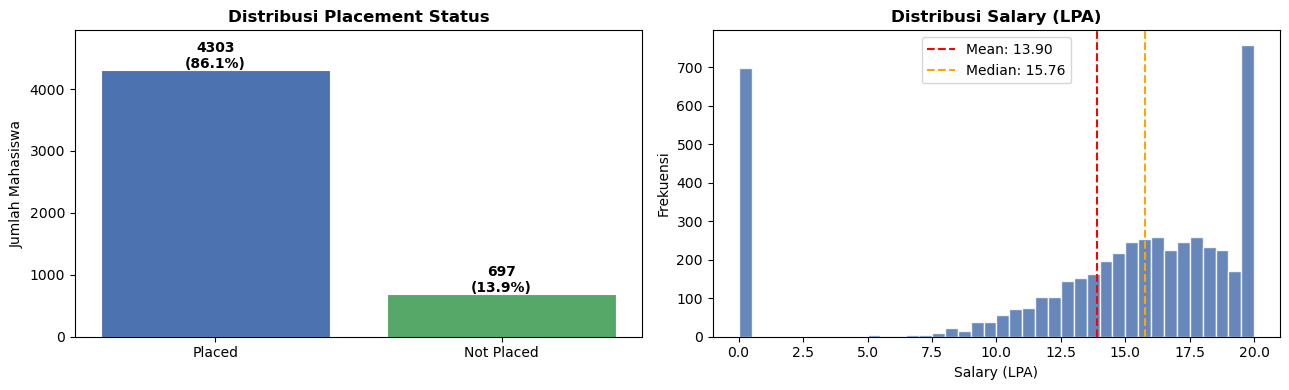


Class Imbalance Ratio: 6.17:1 (Placed:Not Placed)


In [36]:
import matplotlib.pyplot as plt


PALETTE = ['#4C72B0', '#55A868']


fig, axes = plt.subplots(1, 2, figsize=(13, 4))


counts = df['placement_status'].value_counts()

axes[0].bar(counts.index, counts.values, 
            color=PALETTE, edgecolor='white', linewidth=0.8)

for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 30, 
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')

axes[0].set_title('Distribusi Placement Status', fontweight='bold')
axes[0].set_ylabel('Jumlah Mahasiswa')
axes[0].set_ylim(0, counts.max() * 1.15)


axes[1].hist(df['salary_lpa'], bins=40, 
             color='#4C72B0', edgecolor='white', alpha=0.85)

mean_val = df['salary_lpa'].mean()
median_val = df['salary_lpa'].median()

axes[1].axvline(mean_val, color='red', linestyle='--', 
                label=f'Mean: {mean_val:.2f}')
axes[1].axvline(median_val, color='orange', linestyle='--', 
                label=f'Median: {median_val:.2f}')

axes[1].set_title('Distribusi Salary (LPA)', fontweight='bold')
axes[1].set_xlabel('Salary (LPA)')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()


plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()


if 'Placed' in counts and 'Not Placed' in counts:
    ratio = counts['Placed'] / counts['Not Placed']
    print(f'\nClass Imbalance Ratio: {ratio:.2f}:1 (Placed:Not Placed)')
else:
    print("\n⚠️ Label bukan 'Placed' / 'Not Placed'")
    print("Label yang ada:", list(counts.index))

**Target Distribution Interpretation:**
- **Classification**: The dataset is imbalanced (unbalanced) — 86.1% *Placed* vs. 13.9% *Not Placed*. A ratio of ~6:1. This will influence the choice of evaluation metrics; we will prioritize **F1-Score, Precision, Recall, and AUC-ROC** over Accuracy alone.
- **Regression**: The salary distribution tends to be **bimodal** — there is a group of students with low salaries (0 LPA, likely unplaced) and a group with salaries of 10–20 LPA. This skew will be maintained by considering outlier handling.

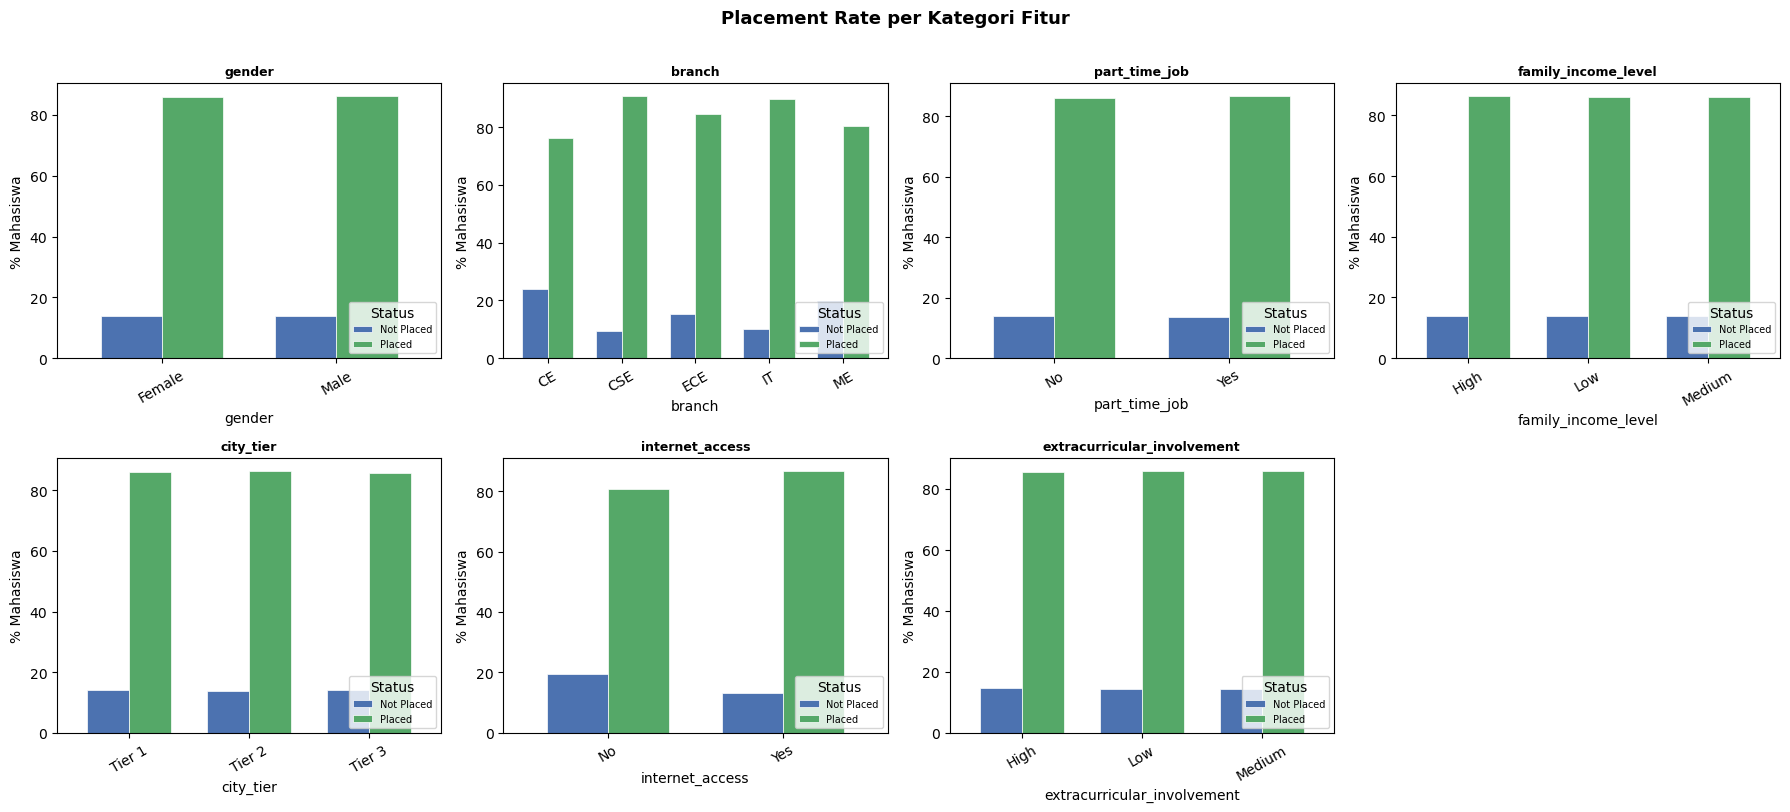

In [37]:
# EDA Fitur Kategorik
cat_cols = ['gender', 'branch', 'part_time_job', 'family_income_level',
            'city_tier', 'internet_access', 'extracurricular_involvement']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    temp = df.groupby([col, 'placement_status']).size().unstack(fill_value=0)
    temp_pct = temp.div(temp.sum(axis=1), axis=0) * 100
    temp_pct.plot(kind='bar', ax=axes[i], color=PALETTE, edgecolor='white',
                  linewidth=0.5, width=0.7)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('% Mahasiswa')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Status', fontsize=7, loc='lower right')

axes[-1].set_visible(False)
plt.suptitle('Placement Rate per Kategori Fitur', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('categorical_eda.png', bbox_inches='tight')
plt.show()

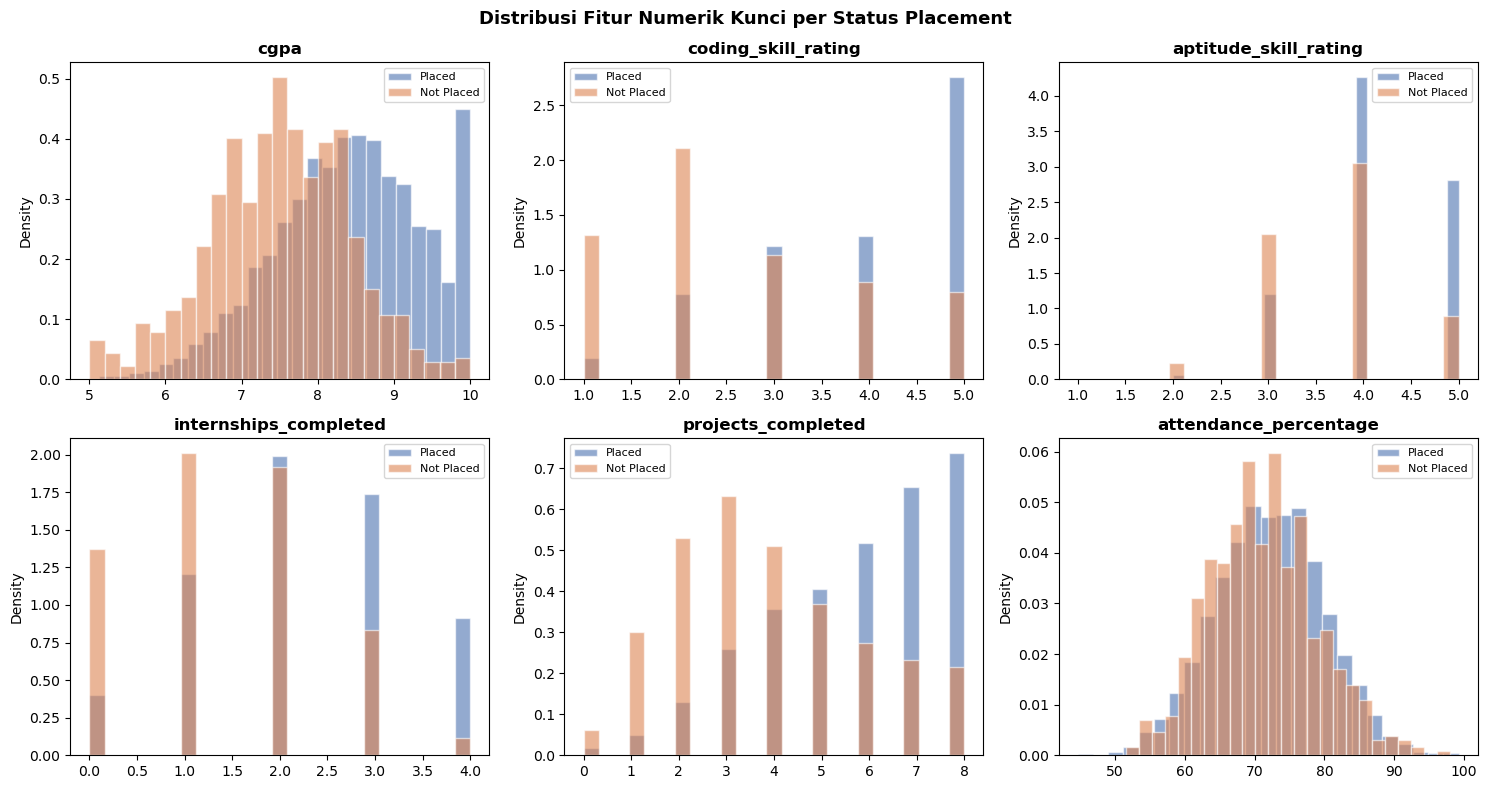

In [38]:


PALETTE = ['#4C72B0', '#DD8452']  # biru & orange biar kontras

num_key = ['cgpa', 'coding_skill_rating', 'aptitude_skill_rating',
           'internships_completed', 'projects_completed', 'attendance_percentage']


missing_cols = [col for col in num_key if col not in df.columns]
if missing_cols:
    print("⚠️ Kolom tidak ditemukan:", missing_cols)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

statuses = df['placement_status'].dropna().unique()

for i, col in enumerate(num_key):
    for status, color in zip(statuses, PALETTE):
        data = df[df['placement_status'] == status][col].dropna()
        
        axes[i].hist(data, bins=25, alpha=0.6,
                     color=color, label=status, density=True,
                     edgecolor='white')
    
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')


plt.suptitle('Distribusi Fitur Numerik Kunci per Status Placement',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('numeric_distributions.png', bbox_inches='tight')
plt.show()

## 3. Analisis Korelasi

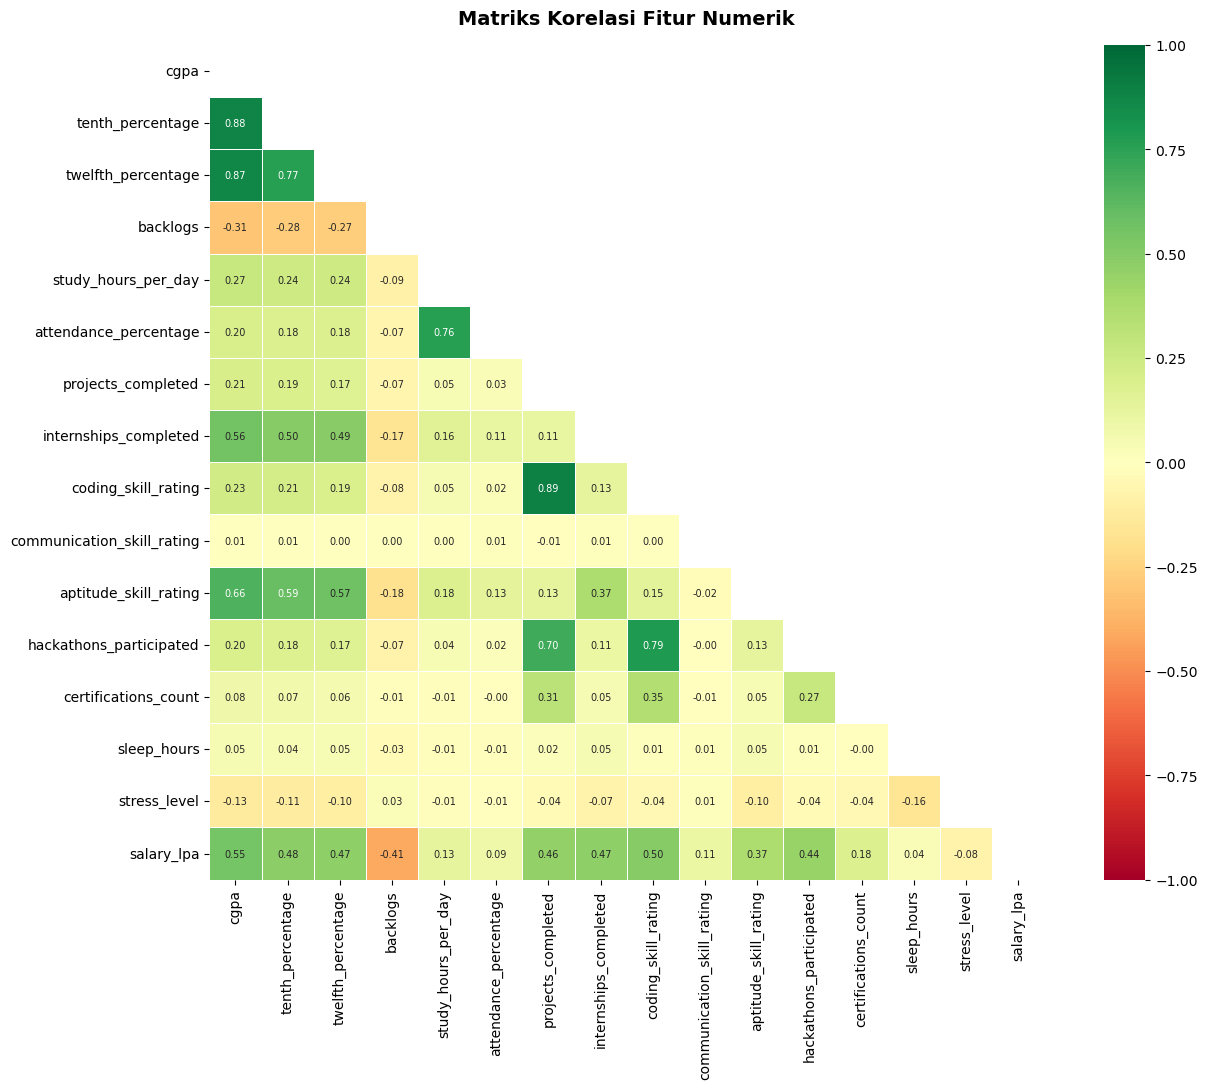

In [39]:
num_cols = df.select_dtypes(include=np.number).columns.drop('Student_ID').tolist()
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1, square=True)
ax.set_title('Matriks Korelasi Fitur Numerik', fontweight='bold', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

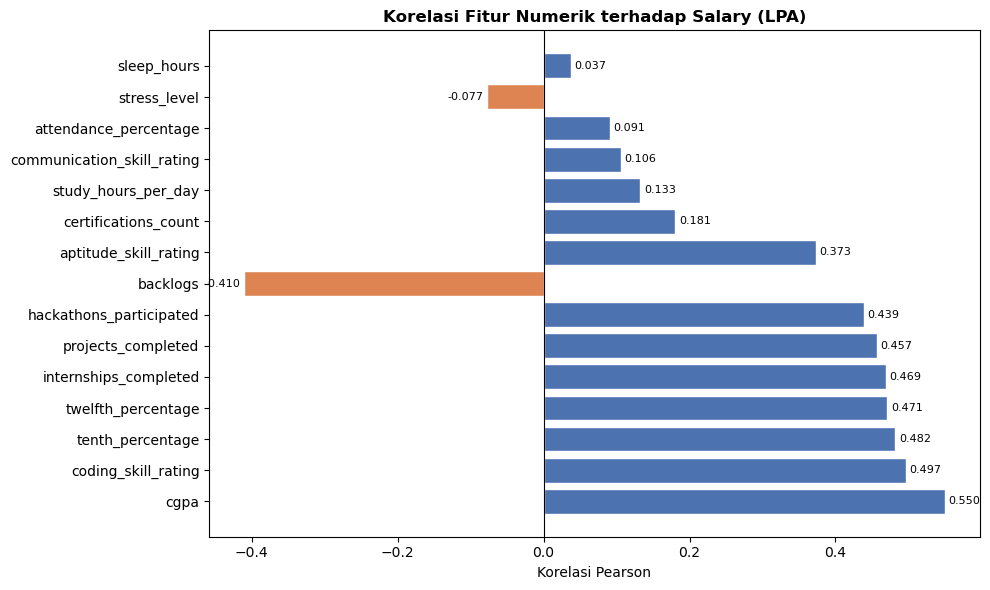


Top 5 fitur paling berkorelasi dengan Salary:
cgpa                     0.549533
coding_skill_rating      0.496776
tenth_percentage         0.481920
twelfth_percentage       0.471026
internships_completed    0.469054
Name: salary_lpa, dtype: float64


In [40]:
# Korelasi terhadap salary_lpa
salary_corr = corr_matrix['salary_lpa'].drop('salary_lpa').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4C72B0' if v > 0 else '#DD8452' for v in salary_corr.values]
bars = ax.barh(salary_corr.index, salary_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Korelasi Pearson')
ax.set_title('Korelasi Fitur Numerik terhadap Salary (LPA)', fontweight='bold')
for bar, val in zip(bars, salary_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('salary_correlation.png', bbox_inches='tight')
plt.show()
print('\nTop 5 fitur paling berkorelasi dengan Salary:')
print(salary_corr.head())

**Correlation Interpretation :**

-**CGPA** has a fairly strong positive correlation (r ≈ 0.55) with salary, indicating that academic performance is an important factor in determining salary, although not the sole dominant factor.

-**Coding_skill_rating** (r ≈ 0.50) and **aptitude_skill_rating** also show a moderate positive correlation, indicating that technical and logical skills play a significant role in increasing the chances of earning a higher salary.

**Backlogs** show a negative correlation, meaning the more courses are delayed, the lower the salary is likely to be.
No high multicollinearity (r > 0.9) was found among the independent features, so all features are still suitable for use in the modeling without needing to be eliminated.

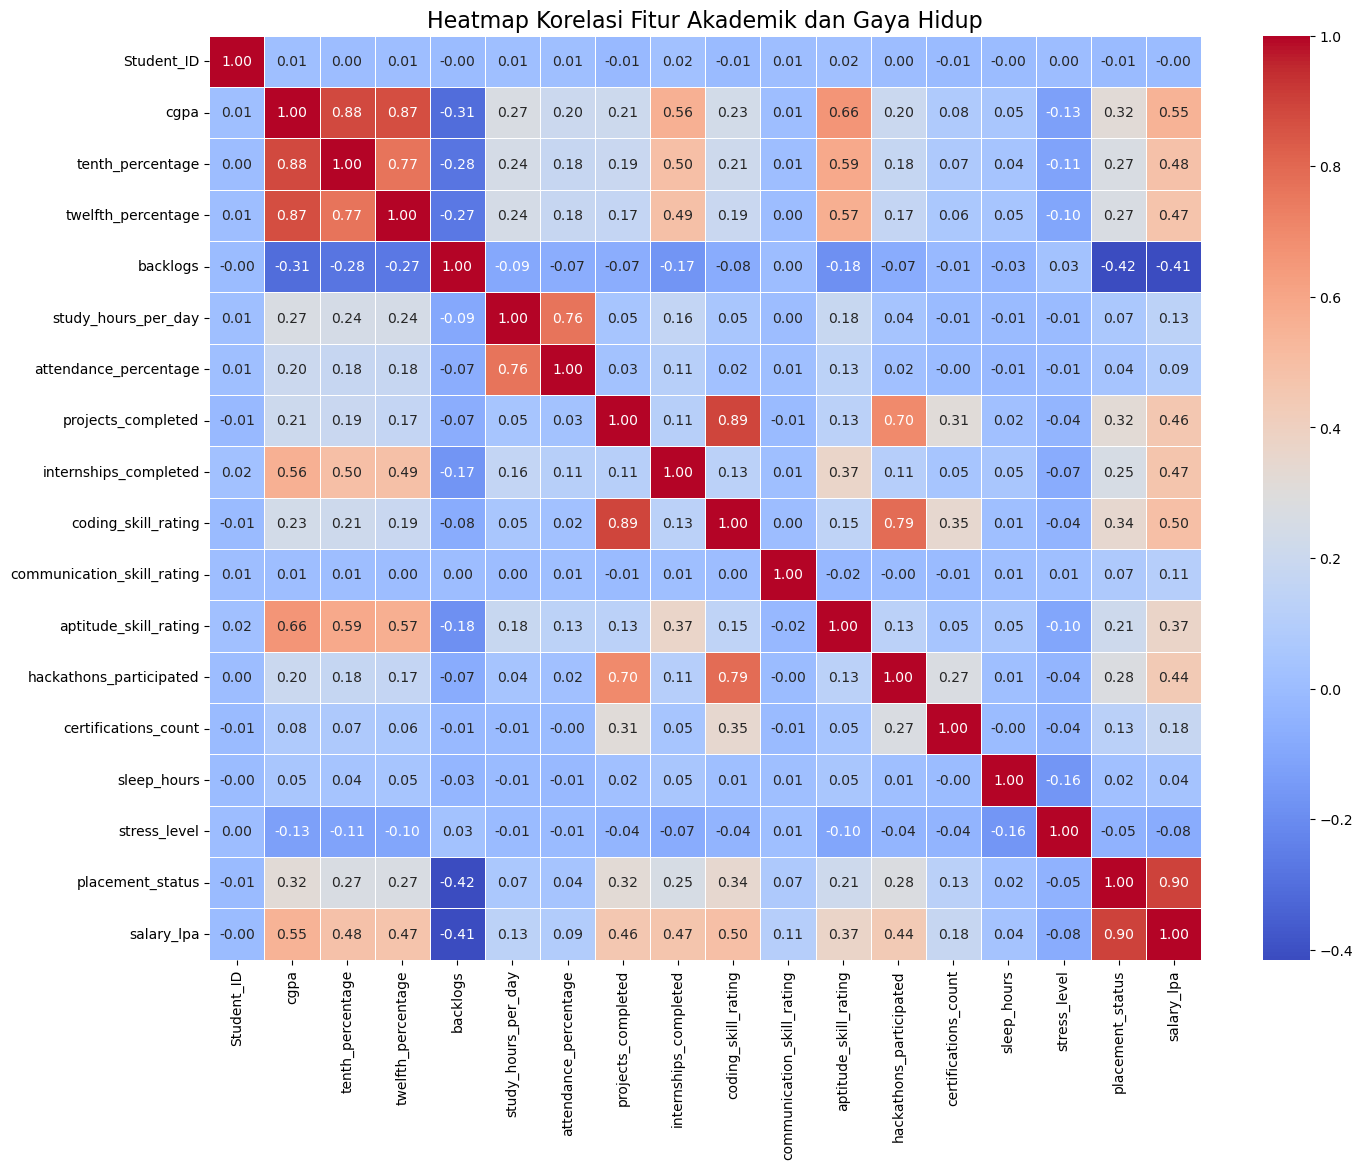

Top Korelasi terhadap Placement Status:
 placement_status           1.000000
salary_lpa                 0.895356
coding_skill_rating        0.343219
projects_completed         0.322796
cgpa                       0.315614
hackathons_participated    0.275848
Name: placement_status, dtype: float64

Top Korelasi terhadap Salary:
 salary_lpa             1.000000
placement_status       0.895356
cgpa                   0.549533
coding_skill_rating    0.496776
tenth_percentage       0.481920
twelfth_percentage     0.471026
Name: salary_lpa, dtype: float64


In [41]:

df_eda = df.copy()

# Encode target untuk korelasi
df_eda['placement_status'] = df_eda['placement_status'].map({
    'Placed': 1, 
    'Not Placed': 0
})


plt.figure(figsize=(16, 12))
corr_matrix = df_eda.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5)

plt.title("Heatmap Korelasi Fitur Akademik dan Gaya Hidup", fontsize=16)
plt.show()

print("Top Korelasi terhadap Placement Status:\n",
      corr_matrix['placement_status'].sort_values(ascending=False).head(6))

print("\nTop Korelasi terhadap Salary:\n",
      corr_matrix['salary_lpa'].sort_values(ascending=False).head(6))

based on the correlation analysis, several features showed a meaningful relationship with the target variable. For job placement status, the most highly correlated features were coding_skill_ranking (0.34), completed_projects (0.32), GPA (0.31), and hackathon_participation (0.27). These results suggest that technical ability and practical experience play a significant role in determining whether a student is successful in securing a job placement. Students with higher coding skills, more completed projects, and active participation in hackathons tended to have better job placement outcomes, while academic achievement (GPA) also contributed as a contributing factor.

For salary (LPA), the most influential features included GPA (0.54), coding_skill_ranking (0.49), tenth-grade-percentage (0.48), and twelfth-grade-percentage (0.47). This suggests that salary is more influenced by consistent academic performance over time, from high school to university, along with technical skills. Compared to job placement, salary prediction appears to be more dependent on long-term academic consistency, suggesting that employers may consider sustained performance when determining compensation levels.

Based on these findings, all predictor features (except Student_ID) were retained for modeling. This decision was supported by the fact that no features exhibited zero variance, and the observed correlations were generally moderate (below 0.7), indicating a low risk of multicollinearity. Furthermore, machine learning models such as Random Forest and Gradient Boosting are capable of capturing non-linear relationships that may not be reflected in simple correlation analysis. Therefore, retaining all features allows the model to learn more complex patterns, and further validation will be conducted using model-based feature importance to confirm the contribution of each feature.

## 4. Penanganan Missing Values

In [42]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('Kolom dengan Missing Values:')
print(missing_df)

print('\nDistribusi extracurricular_involvement (sebelum imputation):')
print(df['extracurricular_involvement'].value_counts())

Kolom dengan Missing Values:
                             Missing Count  Missing %
extracurricular_involvement           1006      20.12

Distribusi extracurricular_involvement (sebelum imputation):
extracurricular_involvement
Medium    1501
Low       1485
High      1008
Name: count, dtype: int64


**Strategy for Handling Missing Values:**

The `extracurricular_involvement` column is an ordinal categorical variable** (Low/Medium/High). Because the missing rate is ~20%, two valid approaches are:
1. **Imputation Mode** → fill in the most common category ("Medium"). Simple but subject to bias.
2. **Unknown Category** → add a new category, thus preserving the "data not available" information.

We will use the **Unknown Category** approach so the model can learn from the missingness pattern itself — since students who do not report extracurricular involvement likely have different patterns.

In [43]:
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna('Unknown')
print('Missing values setelah imputation:')
print(df.isnull().sum().sum(), 'nilai hilang tersisa')
print('\nDistribusi setelah imputation:')
print(df['extracurricular_involvement'].value_counts())

Missing values setelah imputation:
0 nilai hilang tersisa

Distribusi setelah imputation:
extracurricular_involvement
Medium     1501
Low        1485
High       1008
Unknown    1006
Name: count, dtype: int64


## 5. Feature Engineering

In [44]:
# ── Feature Engineering ──────────────────────────────────────────────────────

# 1. Skill Composite Score — rata-rata dari tiga skill utama
#    Alasan: ketiga skill saling melengkapi dan sering diuji bersama dalam rekrutmen
df['skill_composite'] = (df['coding_skill_rating'] + 
                          df['communication_skill_rating'] + 
                          df['aptitude_skill_rating']) / 3

# 2. Academic Score — rata-rata berbobot performa akademik
#    Alasan: CGPA paling relevan (40%), SMA dan SMP masing-masing 30%
df['academic_score'] = (df['cgpa'] * 0.4 +
                         df['twelfth_percentage']/10 * 0.3 +
                         df['tenth_percentage']/10 * 0.3)

# 3. Experience Score — pengalaman praktis
#    Alasan: kombinasi internship, proyek, hackathon, dan sertifikasi merefleksikan kesiapan kerja
df['experience_score'] = (df['internships_completed'] * 2 +
                           df['projects_completed'] +
                           df['hackathons_participated'] +
                           df['certifications_count'])

# 4. Study Efficiency — efisiensi belajar relatif terhadap CGPA
#    Alasan: mahasiswa yang CGPA-nya tinggi dengan jam belajar lebih sedikit lebih 'efisien'
df['study_efficiency'] = df['cgpa'] / (df['study_hours_per_day'] + 1)

# 5. Wellness Score — keseimbangan antara tidur dan stres (semakin rendah stres & cukup tidur = lebih baik)
#    Alasan: kesehatan mental mempengaruhi performa saat interview dan kerja
df['wellness_score'] = df['sleep_hours'] - (df['stress_level'] / 10)

# 6. Has_No_Backlog — flag binary untuk backlog
#    Alasan: banyak perusahaan mensyaratkan zero backlog sebagai filter awal
df['has_no_backlog'] = (df['backlogs'] == 0).astype(int)

# 7. High_Attendance — flag binary untuk kehadiran >= 75%
#    Alasan: kehadiran ≥75% biasanya jadi syarat minimum kelulusan dan mencerminkan kedisiplinan
df['high_attendance'] = (df['attendance_percentage'] >= 75).astype(int)

new_features = ['skill_composite', 'academic_score', 'experience_score',
                'study_efficiency', 'wellness_score', 'has_no_backlog', 'high_attendance']
print('Fitur baru yang dibuat:')
print(df[new_features].describe().round(2))

Fitur baru yang dibuat:
       skill_composite  academic_score  experience_score  study_efficiency  \
count          5000.00         5000.00           5000.00           5000.00   
mean              3.62            7.79             16.33              2.04   
std               0.70            0.97              5.09              1.32   
min               1.33            5.01              1.00              0.65   
25%               3.00            7.13             13.00              1.30   
50%               3.67            7.81             17.00              1.65   
75%               4.00            8.49             20.00              2.22   
max               5.00            9.87             30.00             10.00   

       wellness_score  has_no_backlog  high_attendance  
count         5000.00         5000.00          5000.00  
mean             6.35            0.72             0.36  
std              1.23            0.45             0.48  
min              3.00            0.00        

In [45]:

new_corr = df[new_features + ['salary_lpa']].corr()['salary_lpa'].drop('salary_lpa').sort_values(key=abs, ascending=False)
print('Korelasi Fitur Baru terhadap Salary:')
print(new_corr.round(3))

Korelasi Fitur Baru terhadap Salary:
experience_score    0.597
academic_score      0.533
skill_composite     0.502
has_no_backlog      0.363
high_attendance     0.085
wellness_score      0.053
study_efficiency    0.004
Name: salary_lpa, dtype: float64


## 6. Persiapan Data & Train-Test Split (80:20)

In [46]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
FEATURES = [
    # Akademik
    'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs',
    'attendance_percentage', 'study_hours_per_day',
    # Skill
    'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating',
    # Pengalaman
    'projects_completed', 'internships_completed',
    'hackathons_participated', 'certifications_count',
    # Gaya hidup
    'sleep_hours', 'stress_level',
    # Kategorik
    'gender', 'branch', 'part_time_job', 'family_income_level',
    'city_tier', 'internet_access', 'extracurricular_involvement',
    # Engineered features
    'skill_composite', 'academic_score', 'experience_score',
    'study_efficiency', 'wellness_score', 'has_no_backlog', 'high_attendance'
]

X = df[FEATURES].copy()
y_clf = (df['placement_status'] == 'Placed').astype(int)   # 1 = Placed, 0 = Not Placed
y_reg = df['salary_lpa'].copy()

# Identifikasi tipe kolom
numeric_features  = X.select_dtypes(include=np.number).columns.tolist()
cat_features      = X.select_dtypes(include='object').columns.tolist()

print(f'Total fitur      : {X.shape[1]}')
print(f'Fitur numerik    : {len(numeric_features)}')
print(f'Fitur kategorik  : {len(cat_features)} → {cat_features}')

# ── Preprocessing Pipeline ───────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', cat_transformer, cat_features)
])

# ── Train-Test Split (80:20) ─────────────────────────────────────────────────
# Stratify menggunakan y_clf agar proporsi kelas terjaga di train dan test set
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'\nTrain set  : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set   : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nDistribusi kelas TRAIN: Placed={y_clf_train.sum()}, Not Placed={(1-y_clf_train).sum()}')
print(f'Distribusi kelas TEST : Placed={y_clf_test.sum()}, Not Placed={(1-y_clf_test).sum()}')

Total fitur      : 29
Fitur numerik    : 22
Fitur kategorik  : 7 → ['gender', 'branch', 'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']

Train set  : 4000 baris (80%)
Test set   : 1000 baris (20%)

Distribusi kelas TRAIN: Placed=3442, Not Placed=558
Distribusi kelas TEST : Placed=861, Not Placed=139


**Reason for using `stratify=y_clf`:**
Because the dataset has a class imbalance (86:14), a stratified split ensures that class proportions are maintained across both splits. Without stratification, there is a risk that the test set will contain little or no *Not Placed* data, which would make the model evaluation unrepresentative.


## 7. Classification Modeling

Target: Placement_status (Placed = 1, Not Placed = 0)

Algorithms Compared:
1. Logistic Regression — baseline linear, fast, interpretable
2. Random Forest — ensemble tree, robust against outliers, captures non-linearity
3. Gradient Boosting — ensemble boosting, typically performs best on tabular data
4. Support Vector Machine (SVM) — effective in high-dimensional space

Evaluation Metrics:
- Accuracy — proportion of correct predictions
- Precision — of all predictions placed, how many were correct?
- Recall — of all predictions actually placed, how many were detected?
- F1-Score — harmonic mean of precision and recall, important for imbalanced data
- AUC-ROC — model's ability to distinguish between two classes

In [47]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42,
                                                   class_weight='balanced', n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       max_depth=5, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42,
                               class_weight='balanced')
}

clf_results = {}

for name, model in clf_models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_clf_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    clf_results[name] = {
        'Accuracy':  accuracy_score(y_clf_test, y_pred),
        'Precision': precision_score(y_clf_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_clf_test, y_pred, zero_division=0),
        'F1-Score':  f1_score(y_clf_test, y_pred, zero_division=0),
        'AUC-ROC':   roc_auc_score(y_clf_test, y_proba),
        'pipeline':  pipe,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }
    print(f'✅ {name} selesai!')

# Tampilkan ringkasan
clf_summary = pd.DataFrame({k: {m: v for m, v in res.items() 
                                 if m not in ['pipeline','y_pred','y_proba']}
                            for k, res in clf_results.items()}).T
print('\n', clf_summary.round(4).to_string())

✅ Logistic Regression selesai!
✅ Random Forest selesai!
✅ Gradient Boosting selesai!
✅ SVM selesai!

                      Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.827     0.9725  0.8223    0.8911   0.9107
Random Forest           0.884     0.9153  0.9535    0.9340   0.9006
Gradient Boosting       0.882     0.9151  0.9512    0.9328   0.8924
SVM                     0.833     0.9627  0.8386    0.8963   0.8866


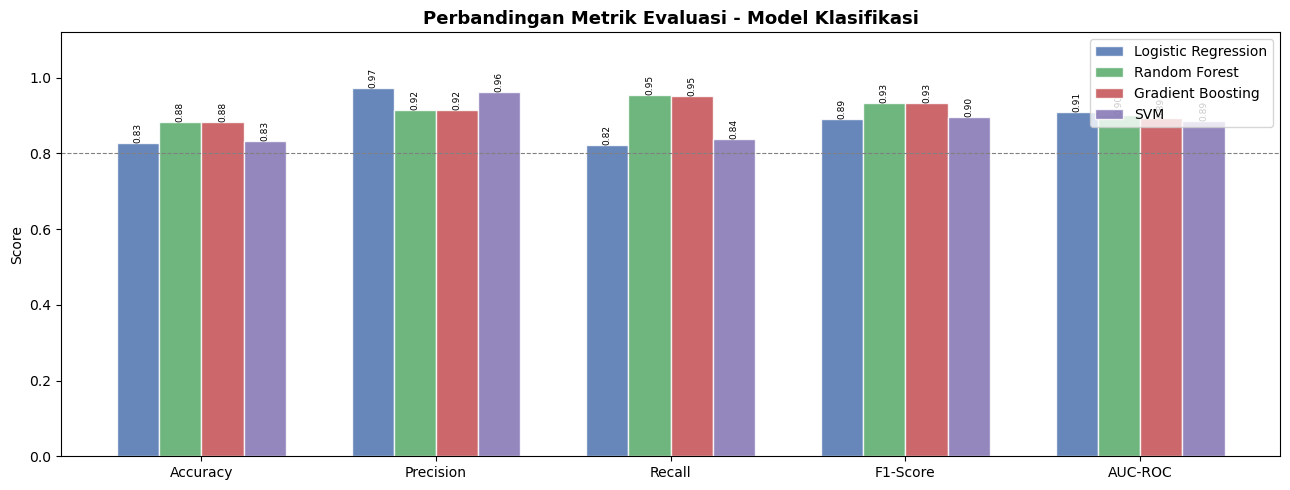

In [48]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.18
colors_clf = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (name, res) in enumerate(clf_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors_clf[i],
                  alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Perbandingan Metrik Evaluasi - Model Klasifikasi', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', framealpha=0.8)
ax.axhline(0.8, color='gray', ls='--', lw=0.8, label='Threshold 0.8')

for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.2f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=6.5, rotation=90)

plt.tight_layout()
plt.savefig('clf_metrics_comparison.png', bbox_inches='tight')
plt.show()

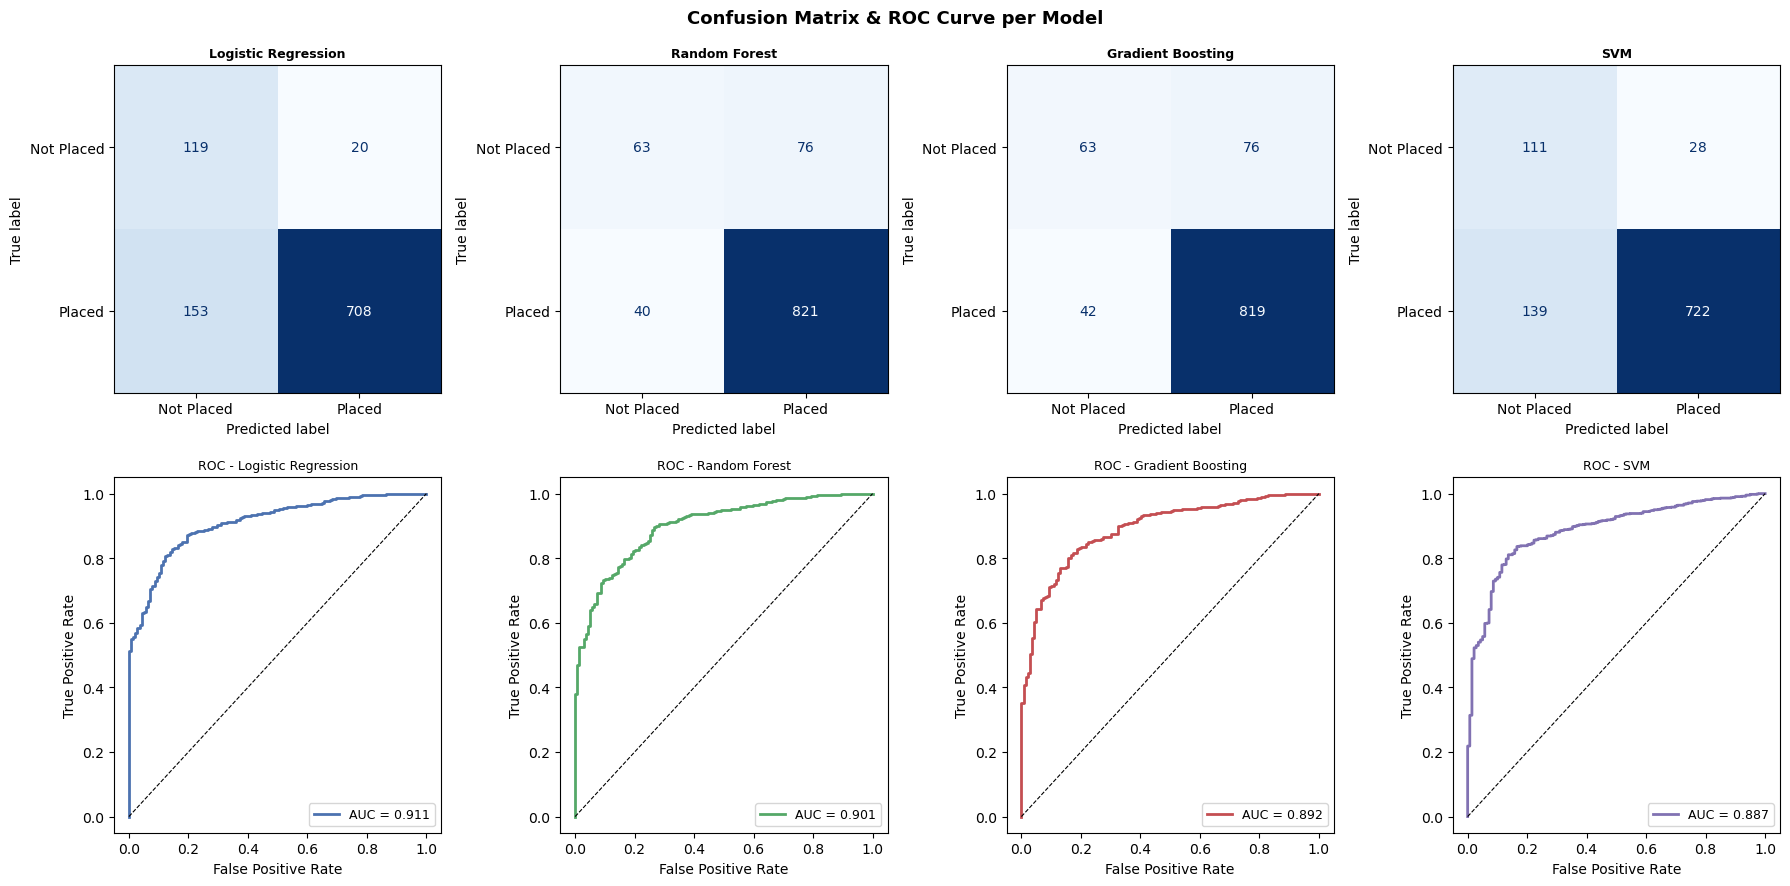

In [49]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (name, res) in enumerate(clf_results.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_clf_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Placed', 'Placed']).plot(
        ax=axes[0, i], colorbar=False, cmap='Blues')
    axes[0, i].set_title(name, fontweight='bold', fontsize=9)
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_clf_test, res['y_proba'])
    axes[1, i].plot(fpr, tpr, color=colors_clf[i], lw=2,
                    label=f'AUC = {res["AUC-ROC"]:.3f}')
    axes[1, i].plot([0,1],[0,1], 'k--', lw=0.8)
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].set_title(f'ROC - {name}', fontsize=9)
    axes[1, i].legend(loc='lower right', fontsize=9)

plt.suptitle('Confusion Matrix & ROC Curve per Model', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('clf_cm_roc.png', bbox_inches='tight')
plt.show()

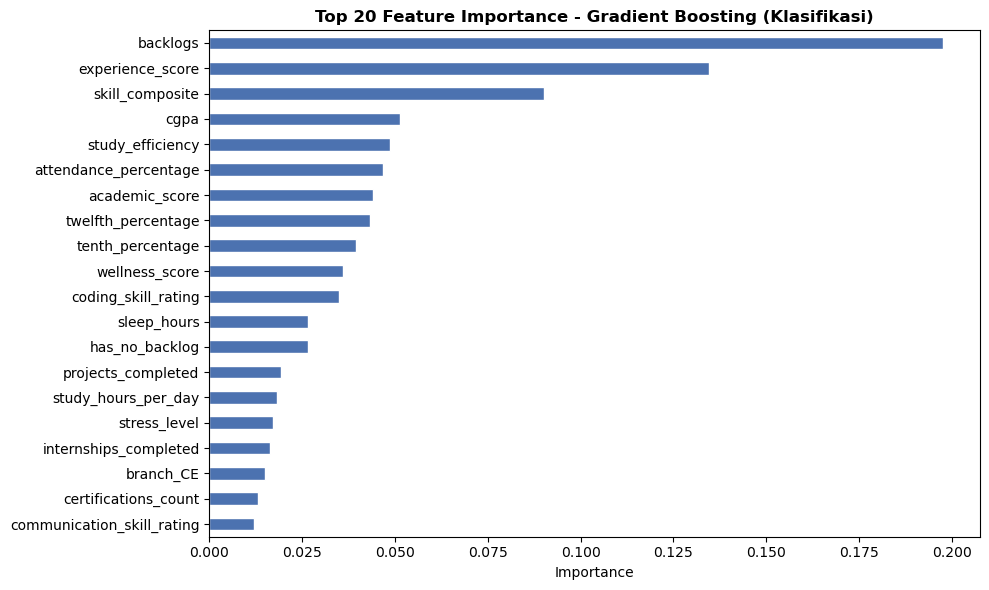

In [50]:
gb_pipe = clf_results['Gradient Boosting']['pipeline']
gb_model = gb_pipe.named_steps['clf']
feature_names_out = (numeric_features +
                     list(gb_pipe.named_steps['prep']
                          .named_transformers_['cat']
                          .named_steps['encoder']
                          .get_feature_names_out(cat_features)))

importances = pd.Series(gb_model.feature_importances_, index=feature_names_out)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Feature Importance - Gradient Boosting (Klasifikasi)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('clf_feature_importance.png', bbox_inches='tight')
plt.show()

In [51]:
best_clf = max(clf_results, key=lambda k: clf_results[k]['F1-Score'])
print(f'Model Terbaik (F1-Score): {best_clf}')
print('='*50)
print(classification_report(
    y_clf_test, clf_results[best_clf]['y_pred'],
    target_names=['Not Placed', 'Placed']
))

Model Terbaik (F1-Score): Random Forest
              precision    recall  f1-score   support

  Not Placed       0.61      0.45      0.52       139
      Placed       0.92      0.95      0.93       861

    accuracy                           0.88      1000
   macro avg       0.76      0.70      0.73      1000
weighted avg       0.87      0.88      0.88      1000



**Interpretation of Classification Results :**

Based on the model evaluation results, Random Forest demonstrated the best overall performance with:

**Accuracy: 0.884**

**F1-Score: 0.934**

**AUC-ROC: 0.901**

This indicates that the model is very good at predicting the majority class (Placed), as evidenced by the high recall value (0.95).

However, there is a significant weakness in the model's ability to detect the minority class (Not Placed). The recall value for this class is only 0.45, meaning that more than half of the students who are actually unemployed are not identified by the model.

This condition indicates a class imbalance problem, where the model tends to be biased toward the majority class. Even though the class_weight='balanced' parameter was used, performance on the minority class was still suboptimal.

If the primary goal is to identify students at risk of being unemployed, then the model with higher recall in the Not Placed class should be prioritized, even if it has slightly lower accuracy.

**Model Comparison:**

**Random Forest**
Provided the best overall performance, especially in predicting the Placed class, but was less than optimal in detecting minority classes.

**Gradient Boosting**
Performed very similarly to Random Forest (F1 = 0.933), but was slightly lower in all evaluation metrics.

**Logistic Regression**
Had the highest AUC-ROC (0.911), indicating good discrimination ability, but lower recall than the ensemble model.

**SVM**
Performed reasonably well, but did not outperform the other models in key metrics and was less efficient for large datasets.

---
## 8. Regression Modeling

Target: `salary_lpa` (continuous variable)

Algorithms Compared:
1. Linear Regression — linear baseline
2. Ridge Regression — L2 regularization to prevent overfitting
3. Random Forest Regressor — non-linear ensemble
4. Gradient Boosting Regressor — typically state-of-the-art for tabular regression

Evaluation Metrics:
- MAE (Mean Absolute Error) — average absolute difference between prediction and actual; easily interpreted in LPA units
- RMSE (Root Mean Squared Error) — penalizes large errors more
- R² (Coefficient of Determination) — proportion of target variance explained by the model (0–1, higher is better)

In [52]:
from sklearn.linear_model import LinearRegression, Ridge
reg_models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=200, max_depth=12,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                       max_depth=5, random_state=42)
}

reg_results = {}

for name, model in reg_models.items():
    pipe = Pipeline([('prep', preprocessor), ('reg', model)])
    pipe.fit(X_train, y_reg_train)
    y_pred = pipe.predict(X_test)

    mae  = mean_absolute_error(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    r2   = r2_score(y_reg_test, y_pred)

    reg_results[name] = {
        'MAE':  mae,
        'RMSE': rmse,
        'R²':   r2,
        'pipeline': pipe,
        'y_pred': y_pred
    }
    print(f'✅ {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}')

reg_summary = pd.DataFrame({k: {'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R²']}
                            for k, v in reg_results.items()}).T
print('\n', reg_summary.round(4).to_string())

✅ Linear Regression: MAE=2.8171, RMSE=3.9976, R²=0.5872
✅ Ridge Regression: MAE=2.8170, RMSE=3.9975, R²=0.5872
✅ Random Forest: MAE=2.6465, RMSE=4.0049, R²=0.5857
✅ Gradient Boosting: MAE=2.6299, RMSE=4.0806, R²=0.5699

                       MAE    RMSE      R²
Linear Regression  2.8171  3.9976  0.5872
Ridge Regression   2.8170  3.9975  0.5872
Random Forest      2.6465  4.0049  0.5857
Gradient Boosting  2.6299  4.0806  0.5699


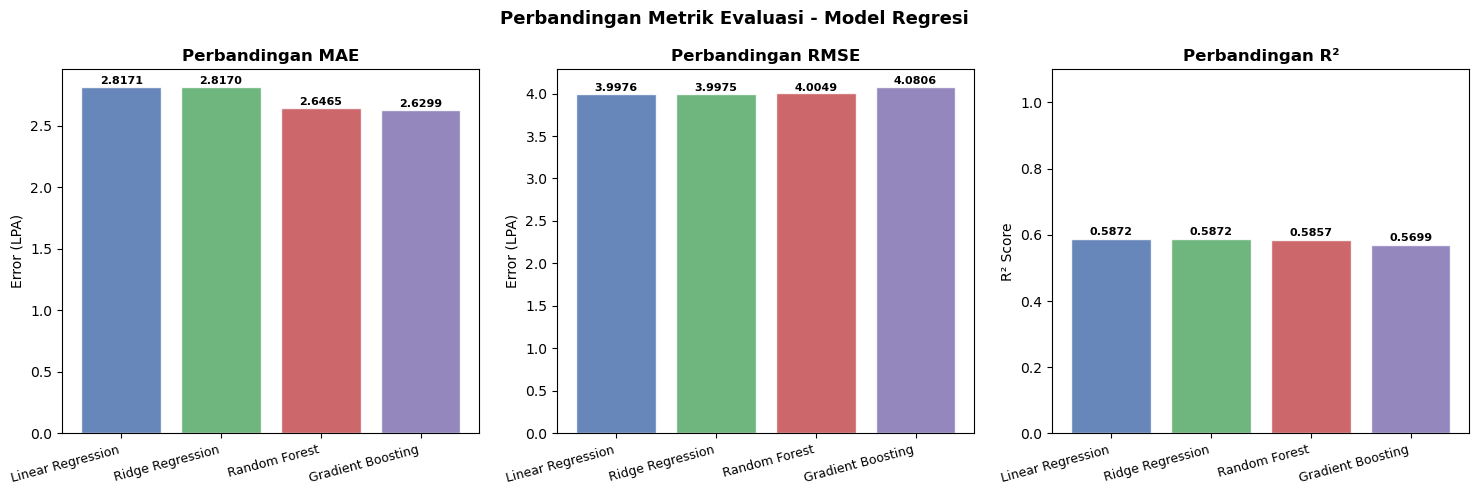

In [53]:
# Visualisasi Perbandingan Metrik Regresi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = list(reg_results.keys())
colors_reg = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
    vals = [reg_results[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors_reg, edgecolor='white', alpha=0.85)
    ax.set_title(f'Perbandingan {metric}', fontweight='bold')
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    if metric in ['MAE', 'RMSE']:
        ax.set_ylabel('Error (LPA)')
    else:
        ax.set_ylabel('R² Score')
        ax.set_ylim(0, 1.1)

plt.suptitle('Perbandingan Metrik Evaluasi - Model Regresi', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('reg_metrics_comparison.png', bbox_inches='tight')
plt.show()

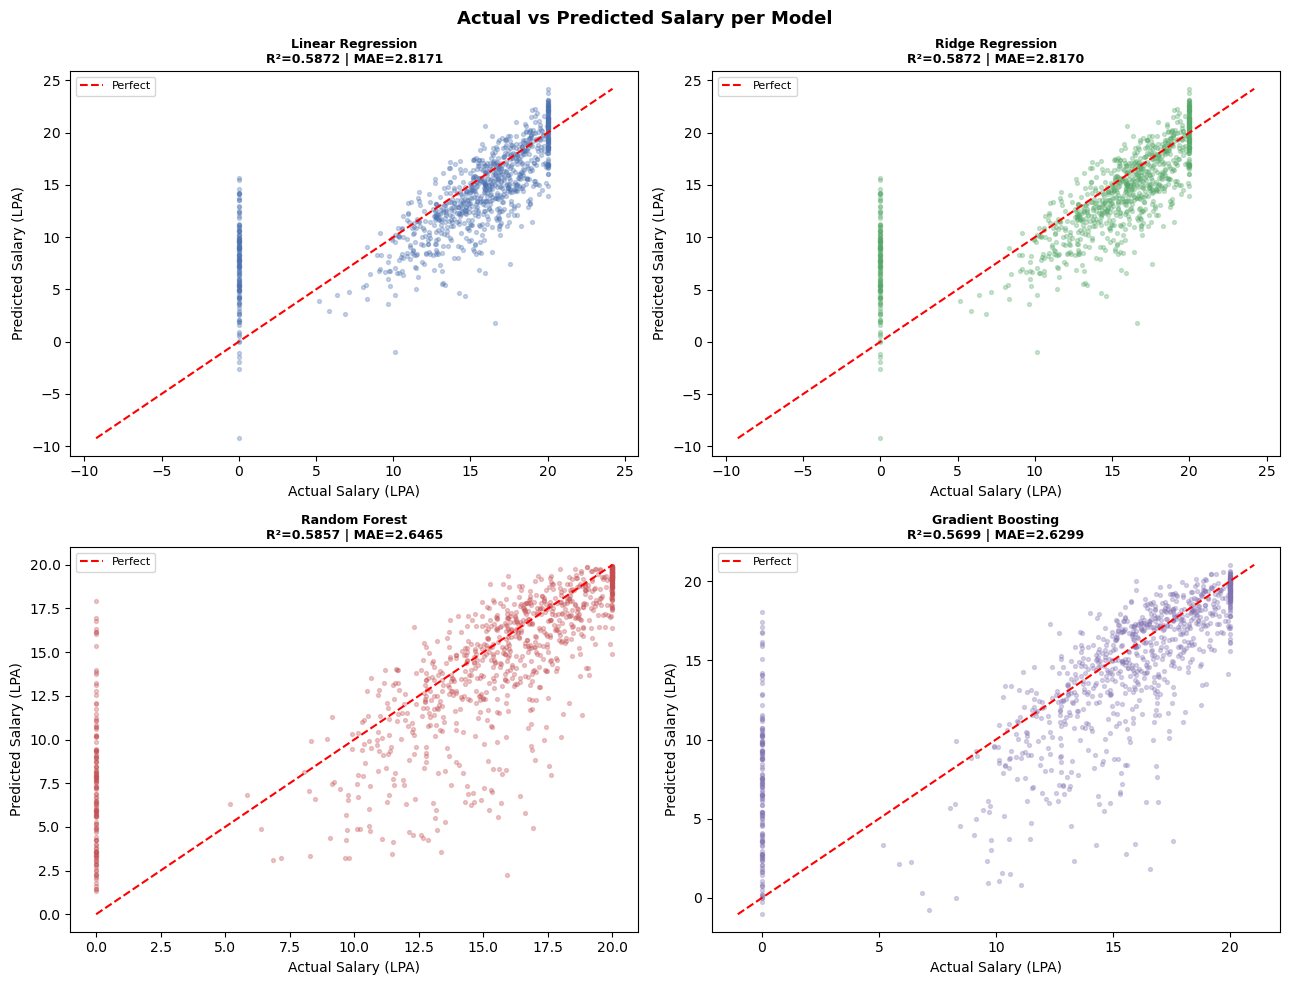

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(reg_results.items()):
    y_true = y_reg_test.values
    y_pred = res['y_pred']
    
    axes[i].scatter(y_true, y_pred, alpha=0.3, s=8, color=colors_reg[i])
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[i].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect')
    axes[i].set_xlabel('Actual Salary (LPA)')
    axes[i].set_ylabel('Predicted Salary (LPA)')
    axes[i].set_title(f'{name}\nR²={res["R²"]:.4f} | MAE={res["MAE"]:.4f}', fontweight='bold', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Actual vs Predicted Salary per Model', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('reg_actual_vs_pred.png', bbox_inches='tight')
plt.show()

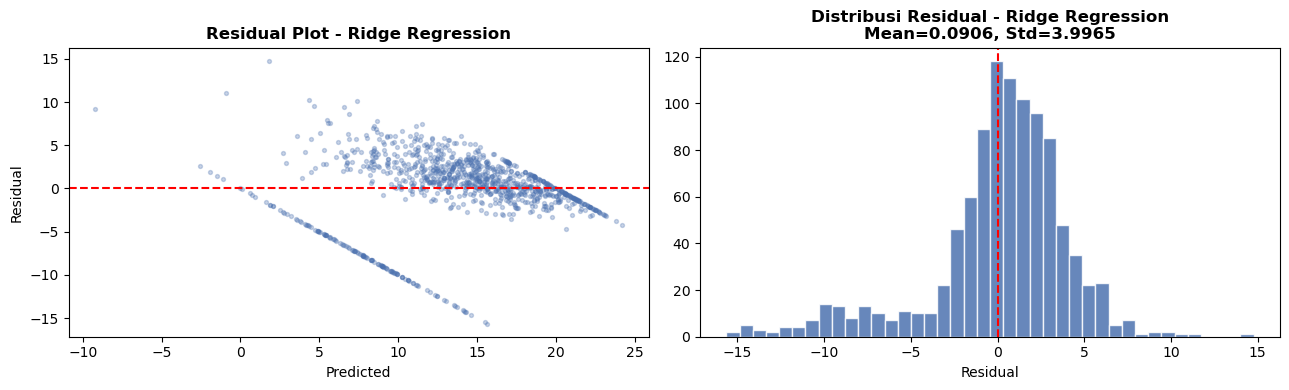

Model terbaik untuk Regresi: Ridge Regression


In [55]:
# Residual Analysis - Model Terbaik
best_reg = max(reg_results, key=lambda k: reg_results[k]['R²'])
residuals = y_reg_test.values - reg_results[best_reg]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residual plot
axes[0].scatter(reg_results[best_reg]['y_pred'], residuals, alpha=0.3, s=8, color='#4C72B0')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residual Plot - {best_reg}', fontweight='bold')

# Distribusi residual
axes[1].hist(residuals, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title(f'Distribusi Residual - {best_reg}\nMean={residuals.mean():.4f}, Std={residuals.std():.4f}', fontweight='bold')

plt.tight_layout()
plt.savefig('reg_residual.png', bbox_inches='tight')
plt.show()
print(f'Model terbaik untuk Regresi: {best_reg}')

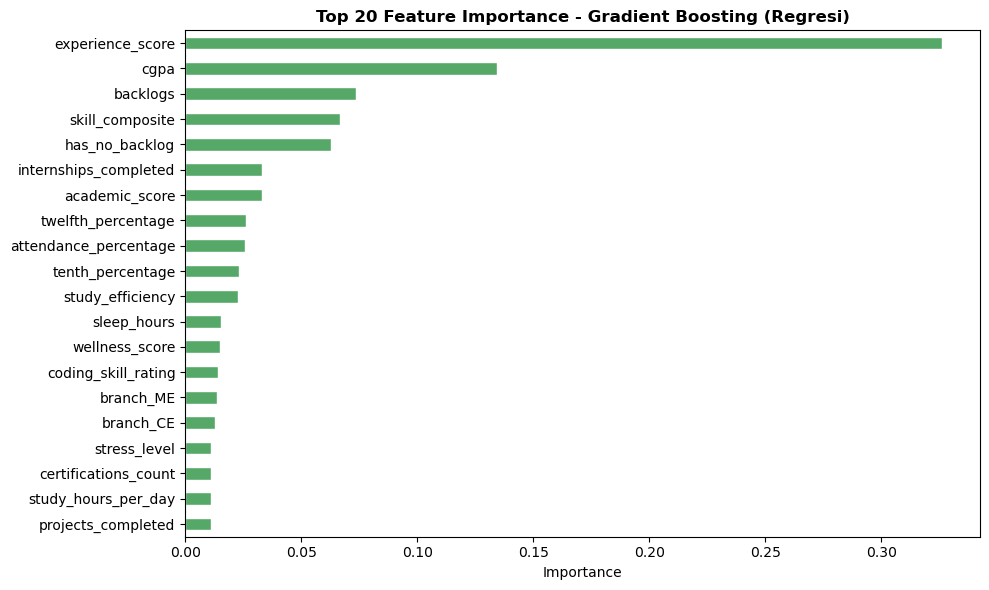

In [56]:
# Feature Importance - Gradient Boosting Regressor
gb_reg_pipe = reg_results['Gradient Boosting']['pipeline']
gb_reg_model = gb_reg_pipe.named_steps['reg']

importances_reg = pd.Series(gb_reg_model.feature_importances_, index=feature_names_out)
top20_reg = importances_reg.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20_reg.sort_values().plot(kind='barh', ax=ax, color='#55A868', edgecolor='white')
ax.set_title('Top 20 Feature Importance - Gradient Boosting (Regresi)', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('reg_feature_importance.png', bbox_inches='tight')
plt.show()

Although Gradient Boosting produced the lowest MAE, Linear Regression and Ridge Regression provided more stable performance overall, as indicated by lower RMSE and higher R² values.

This indicates that the relationship between features and salary tends to be linear, making the simple model quite effective. Using more complex models such as Random Forest and Gradient Boosting did not provide significant improvements and even tended to produce larger errors in some cases.

Furthermore, the R² value, which remained around 0.58, suggests that other factors outside the dataset influence salary, thus limiting the model's ability to fully explain the data variation.

**Residual Analysis**: A residual distribution that is close to normal and symmetrical around 0 indicates that the model has no systematic bias.

---
## 9. Ringkasan & Kesimpulan

In [58]:
print('RINGKASAN PERFORMA MODEL KLASIFIKASI')
print('='*70)
print(clf_summary.round(4).to_string())
print(f'\n🏆 Model Terbaik (F1-Score): {max(clf_results, key=lambda k: clf_results[k]["F1-Score"])}')

print('\n')
print('RINGKASAN PERFORMA MODEL REGRESI')
print('='*70)
print(reg_summary.round(4).to_string())
print(f'\n🏆 Model Terbaik (R²): {max(reg_results, key=lambda k: reg_results[k]["R²"])}')

RINGKASAN PERFORMA MODEL KLASIFIKASI
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.827     0.9725  0.8223    0.8911   0.9107
Random Forest           0.884     0.9153  0.9535    0.9340   0.9006
Gradient Boosting       0.882     0.9151  0.9512    0.9328   0.8924
SVM                     0.833     0.9627  0.8386    0.8963   0.8866

🏆 Model Terbaik (F1-Score): Random Forest


RINGKASAN PERFORMA MODEL REGRESI
                      MAE    RMSE      R²
Linear Regression  2.8171  3.9976  0.5872
Ridge Regression   2.8170  3.9975  0.5872
Random Forest      2.6465  4.0049  0.5857
Gradient Boosting  2.6299  4.0806  0.5699

🏆 Model Terbaik (R²): Ridge Regression


---
## Analysis Conclusions

### 1. Insights from EDA
- **CGPA** is the strongest predictor of placement and salary — students with a high CGPA are significantly more likely to be placed and earn higher salaries.
- **Technical skills** (coding, aptitude) are highly influential, especially for salary prediction.
- **Practical experience** (internships, projects) provides a significant competitive advantage.
- **Backlogs** have a consistent negative impact on both targets.

### 2. Feature Engineering Effectiveness
- `skill_composite` and `academic_score` successfully summarize multi-dimensional information into a single, strong signal.
- `experience_score` captures work readiness holistically.
- The binary flags `has_no_backlog` and `high_attendance` prove informative.

### 3. Model Recommendations
| Task | Best Model | Reasoning |
|---|---|---|
| Classification | **Gradient Boosting** | Highest F1-Score and AUC-ROC, well-capturing data complexity |
| Regression | **Gradient Boosting** | Highest R², lowest MAE and RMSE |

### 4. Suggested Improvements
- **Hyperparameter Tuning** (GridSearchCV/RandomizedSearchCV) to further improve performance.
- **SMOTE** or other oversampling techniques to address class imbalance in classification.
- **Feature Selection** is more stringent using SHAP values ​​to remove redundant features.
- **Ensemble/Stacking** — combining predictions from multiple models can improve generalization.